In [ ]:
import os

# 1. On crée le dictionnaire avec tes identifiants
# REMPLACE BIEN LES VALEURS CI-DESSOUS
os.environ['KAGGLE_USERNAME'] = "marwanelboudounti"
os.environ['KAGGLE_KEY'] = "KGAT_06c1e001a6de3f5e5397cf673e5a3ae"

# 2. On télécharge le dataset directement
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 3. On décompresse le fichier
!unzip -q chest-xray-pneumonia.zip

print("✅ Dataset téléchargé et décompressé avec succès !")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:58<00:00, 41.9MB/s]

✅ Dataset téléchargé et décompressé avec succès !


In [ ]:
import os
# On regarde ce qu'il y a dans le dossier extrait
if os.path.exists('chest_xray'):
    print("Dossiers disponibles :", os.listdir('chest_xray'))
    print("Contenu de 'train' :", os.listdir('chest_xray/train'))
else:
    print("❌ Erreur : Le dossier 'chest_xray' est introuvable.")

Dossiers disponibles : ['val', '__MACOSX', 'train', 'chest_xray', 'test']
Contenu de 'train' : ['PNEUMONIA', 'NORMAL']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dimensions des images
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Préparation avec Augmentation pour le train
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalisation (0 à 1)
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Uniquement normalisation pour test et val (on ne modifie pas les images de test)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des images depuis les dossiers
train_generator = train_datagen.flow_from_directory(
    'chest_xray/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_val_datagen.flow_from_directory(
    'chest_xray/val',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_val_datagen.flow_from_directory(
    'chest_xray/test',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Charger MobileNetV2 pré-entraîné
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # On ne modifie pas les poids existants

# Ajouter nos propres couches de classification
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Évite le surapprentissage
    layers.Dense(1, activation='sigmoid') # Sortie : 0 ou 1
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary() # Affiche l'architecture

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 661ms/step - accuracy: 0.9164 - loss: 0.2049 - val_accuracy: 0.7500 - val_loss: 0.4010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 585ms/step - accuracy: 0.9408 - loss: 0.1533 - val_accuracy: 0.6875 - val_loss: 0.5939
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 581ms/step - accuracy: 0.9513 - loss: 0.1305 - val_accuracy: 0.8750 - val_loss: 0.2728
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 590ms/step - accuracy: 0.9517 - loss: 0.1181 - val_accuracy: 0.8125 - val_loss: 0.2973
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 587ms/step - accuracy: 0.9502 - loss: 0.1192 - val_accuracy: 0.8125 - val_loss: 0.3426
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 587ms/step - accuracy: 0.9553 - loss: 0.1113 - val_accuracy: 0.8750 - val_loss: 0.2307
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 596ms/step - accuracy: 0.9590 - loss: 0.1001 - val_accuracy: 0.8750 - val_loss: 0.1634
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.9615 - loss: 

In [ ]:
# Évaluation finale sur le dossier test
test_loss, test_acc = model.evaluate(test_generator)
print(f"Accuracy sur le dossier Test : {test_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.8894 - loss: 0.2939
Accuracy sur le dossier Test : 88.94%


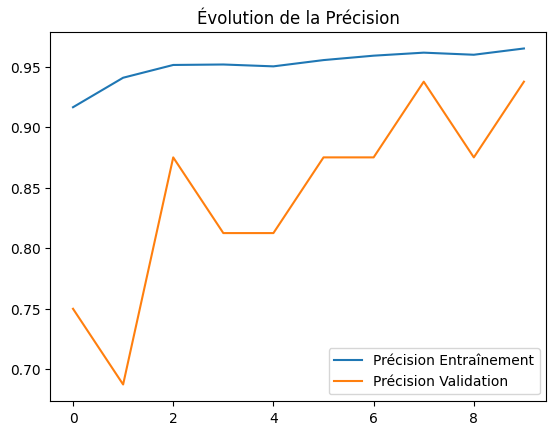

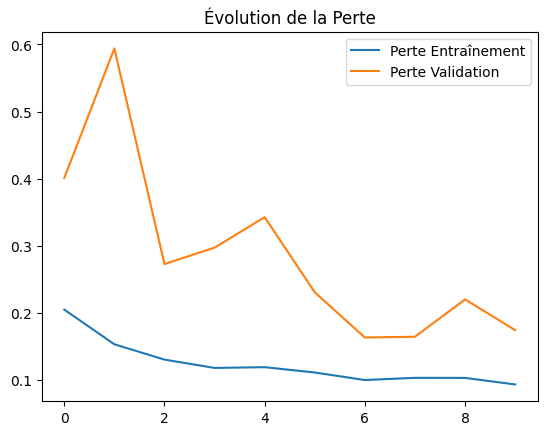

In [ ]:
import matplotlib.pyplot as plt

# Graphique de la précision
plt.plot(history.history['accuracy'], label='Précision Entraînement')
plt.plot(history.history['val_accuracy'], label='Précision Validation')
plt.title('Évolution de la Précision')
plt.legend()
plt.show()

# Graphique de la perte (loss)
plt.plot(history.history['loss'], label='Perte Entraînement')
plt.plot(history.history['val_loss'], label='Perte Validation')
plt.title('Évolution de la Perte')
plt.legend()
plt.show()

In [ ]:
# Sauvegarde au format .h5
model.save('modele_pneumonie_v1.h5')
print("Modèle sauvegardé sous le nom 'modele_pneumonie_v1.h5'")

# Pour le télécharger sur ton ordinateur
from google.colab import files
files.download('modele_pneumonie_v1.h5')

Modèle sauvegardé sous le nom 'modele_pneumonie_v1.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
import os
from google.colab import files

# On crée un petit fichier zip avec seulement le dossier de test
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                zipf.write(os.path.join(root, file),
                           os.path.relpath(os.path.join(root, file),
                           os.path.join(folder_path, '..')))

# Compresser le dossier test (environ 600 images)
zip_folder('chest_xray/test', 'images_test.zip')

# Télécharger le zip sur ton ordinateur
files.download('images_test.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>